# 06. Model Evaluation & Error Analysis

**Tác giả / Nhóm thực hiện:** Real Estate Data Science Team  
**Mô hình chính:** Multiple Linear Regression (`sklearn.linear_model.LinearRegression`)  
**Mục đích:** Đánh giá hiệu năng mô hình trên tập Test ($N=9,172$), trực quan hóa tương quan dự đoán, phân tích sai số (Residual Diagnostics) và phân tích các trường hợp sai lệch lớn nhất.

In [1]:
import sys
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

sys.path.append('../src')
from visualization import (
    plot_actual_vs_predicted,
    plot_residual_distribution,
    plot_residual_vs_predicted,
    plot_absolute_error_distribution,
    plot_error_by_price_range,
    plot_top_prediction_errors
)

# Load data & model
df_feat = pd.read_csv('../data/processed/housing_features.csv')
X = df_feat.drop(columns=['price_million_vnd'])
y = df_feat['price_million_vnd']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = joblib.load('../models/linear_regression.pkl')
y_pred_raw = model.predict(X_test)
y_pred_clipped = np.maximum(y_pred_raw, 0)

print(f"Test Set Size: {len(y_test):,} samples")
print(f"Raw Model R²:   {r2_score(y_test, y_pred_raw):.4f}")
print(f"Raw Model MAE:  {mean_absolute_error(y_test, y_pred_raw):,.2f} million VND")
print(f"Raw Model RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_raw)):,.2f} million VND")

Test Set Size: 9,172 samples
Raw Model R²:   0.3729
Raw Model MAE:  8,418.12 million VND
Raw Model RMSE: 21,435.72 million VND


## 1. GROUP D — MODEL PERFORMANCE VISUALIZATIONS

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Residual vs Predicted Price — Final Linear Regression'}, xlabel='Predicted Price (Million VND)', ylabel='Residual = Actual - Predicted (Million VND)'>)

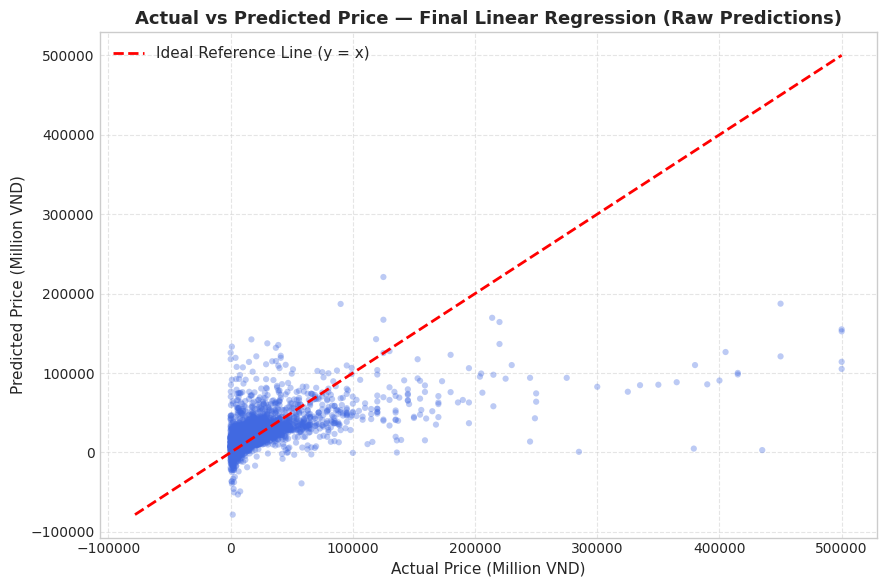

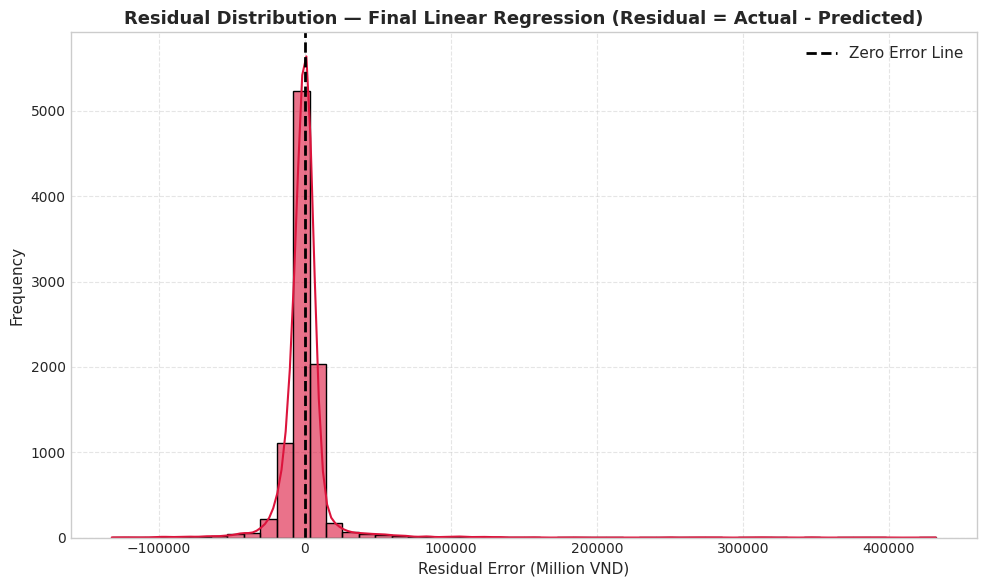

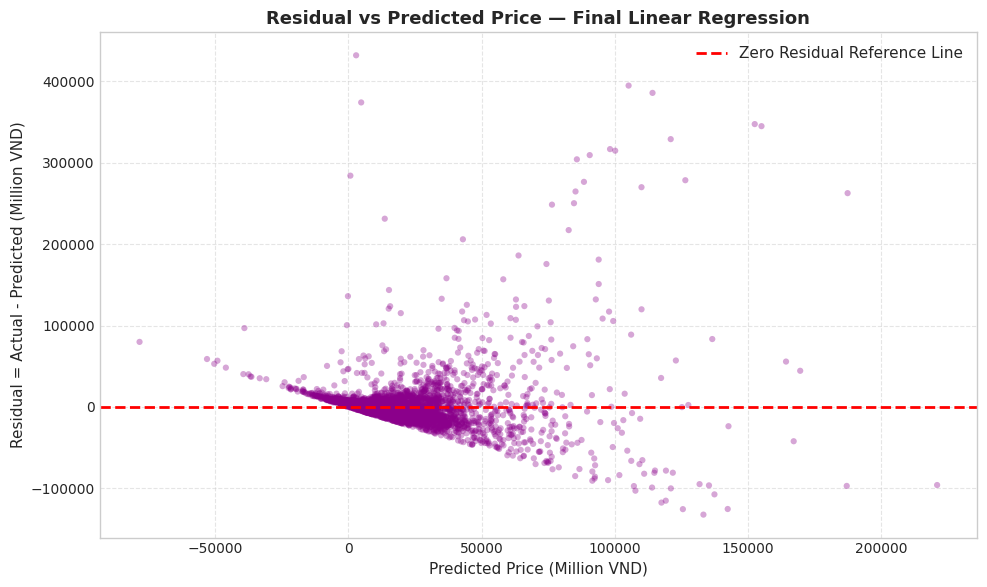

In [2]:
# Figure 10: Actual vs Predicted Price (Raw Predictions)
plot_actual_vs_predicted(y_test, y_pred_raw, save_path='../reports/figures/10_actual_vs_predicted.png', show=True)

# Figure 11: Residual Distribution (Actual - Predicted)
plot_residual_distribution(y_test, y_pred_raw, save_path='../reports/figures/11_residual_distribution.png', show=True)

# Figure 12: Residual vs Predicted Plot
plot_residual_vs_predicted(y_test, y_pred_raw, save_path='../reports/figures/12_residual_vs_predicted.png', show=True)

## 2. GROUP E — ERROR ANALYSIS VISUALIZATIONS

(<Figure size 1200x700 with 1 Axes>,
 <Axes: title={'center': 'Top 20 Largest Prediction Errors (Absolute Error in Million VND)'}, xlabel='Absolute Prediction Error |Actual - Predicted| (Million VND)'>)

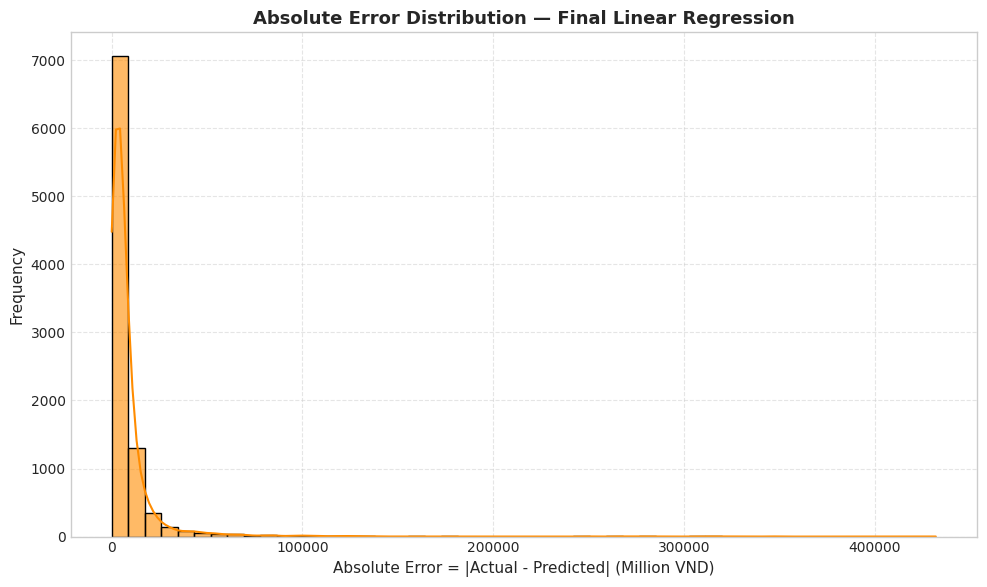

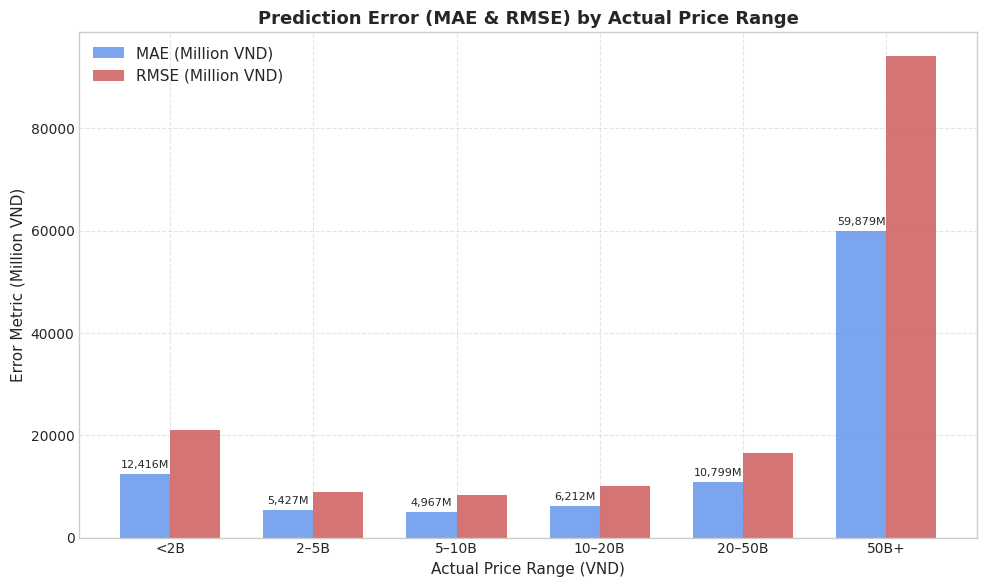

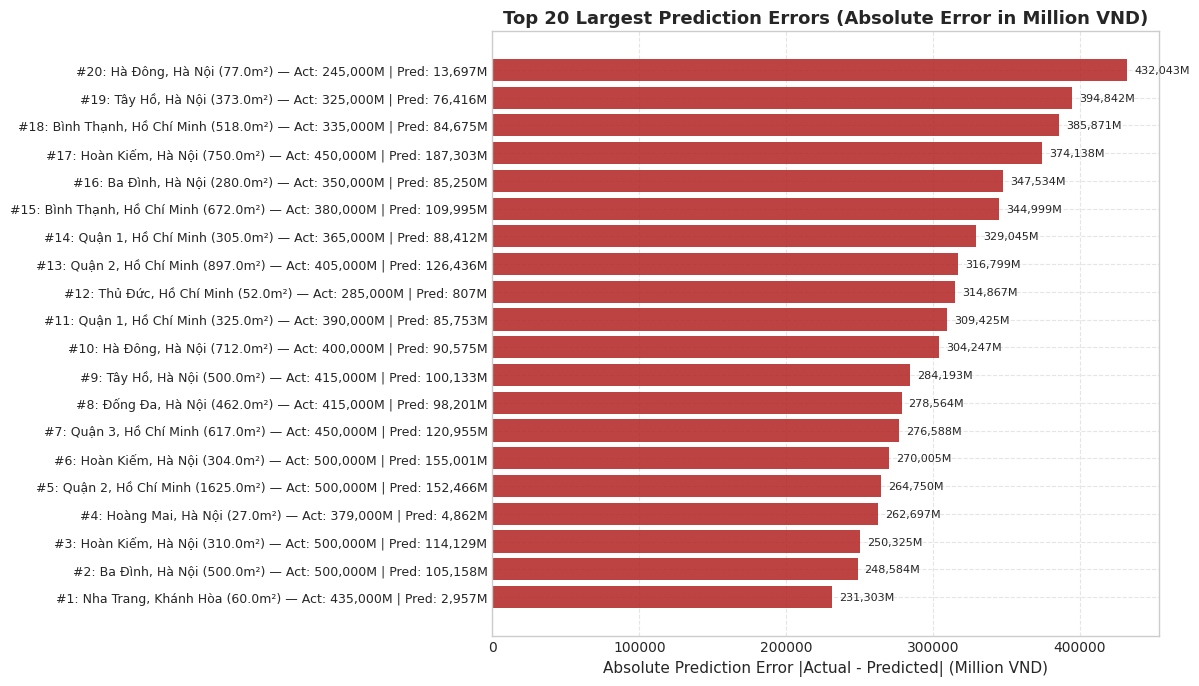

In [3]:
# Figure 13: Absolute Error Distribution
plot_absolute_error_distribution(y_test, y_pred_raw, save_path='../reports/figures/13_absolute_error_distribution.png', show=True)

# Figure 14: Error Metrics across Price Ranges
plot_error_by_price_range(y_test, y_pred_raw, save_path='../reports/figures/14_error_by_price_range.png', show=True)

# Figure 15: Top 20 Prediction Errors
plot_top_prediction_errors(X_test, y_test, y_pred_raw, save_path='../reports/figures/15_top_prediction_errors.png', show=True)